# Analyze DAG files created by tree_to_dag and larch_merge

This notebook analyzes the individual DAGs created from randomized alignments and the merged DAG produced by larch-dagutil.

## Import Python modules

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

## Parse log files and extract statistics

Extract parsimony scores and tree counts from tree_to_dag and larch_merge log files for HA H1 and HA H7.

In [2]:
# Automatically discover all segment-subtype combinations from logs directory
segment_dirs = [d for d in os.listdir('../logs/') if os.path.isdir(os.path.join('../logs/', d))]

# Store statistics for each DAG
dag_stats = []

for segment in segment_dirs:
    subtype_dirs = [d for d in os.listdir(f'../logs/{segment}/') if os.path.isdir(os.path.join(f'../logs/{segment}/', d))]
    for subtype in subtype_dirs:
        print(f"\nProcessing {segment} {subtype}...")
        
        # Get number of randomizations from directory
        randomized_dirs = [d for d in os.listdir(f'../logs/{segment}/{subtype}/')
                          if d.startswith('randomized_') and 
                          os.path.isdir(os.path.join(f'../logs/{segment}/{subtype}/', d))]
        n_randomizations = len(randomized_dirs)
        
        if n_randomizations == 0:
            print(f"  Warning: No randomized directories found, skipping...")
            continue
        
        # Load individual DAGs from randomized runs
        for n in range(n_randomizations):
            log_file = f'../logs/{segment}/{subtype}/randomized_{n}/tree_to_dag.log'
            
            if not os.path.exists(log_file):
                print(f"  Warning: {log_file} not found, skipping...")
                continue
            
            # Read log file
            with open(log_file, 'r') as f:
                log_content = f.read()
            
            # Parse statistics using regex
            min_parsimony_match = re.search(r'Min parsimony score in DAG:\s*(\d+)', log_content)
            max_parsimony_match = re.search(r'Max parsimony score in DAG:\s*(\d+)', log_content)
            tree_count_match = re.search(r'Total trees in DAG:\s*(\d+)', log_content)
            
            if not all([min_parsimony_match, max_parsimony_match, tree_count_match]):
                print(f"  Warning: Could not parse all statistics from {log_file}")
                continue
            
            min_parsimony = int(min_parsimony_match.group(1))
            max_parsimony = int(max_parsimony_match.group(1))
            tree_count = int(tree_count_match.group(1))
            
            dag_stats.append({
                'segment_subtype': f'{segment}_{subtype}',
                'dag_type': 'individual',
                'randomization': n,
                'min_parsimony': min_parsimony,
                'max_parsimony': max_parsimony,
            })
            
            print(f"  Randomization {n}: {min_parsimony} parsimony, {tree_count:,} trees")
        
        # Load merged DAG statistics from larch_merge log
        merged_log_file = f'../logs/{segment}/{subtype}/larch_merge.log'
        
        if os.path.exists(merged_log_file):
            # Read log file
            with open(merged_log_file, 'r') as f:
                log_content = f.read()
            
            # Parse statistics using regex
            parsimony_min_match = re.search(r'parsimony_min:\s*score:(\d+)', log_content)
            parsimony_max_match = re.search(r'parsimony_max:\s*score:(\d+)', log_content)
            tree_count_match = re.search(r'tree_count:\s*(\d+)', log_content)
            num_leaves_match = re.search(r'DAG leave\(without trimming\):\s*(\d+)', log_content)
            num_nodes_match = re.search(r'DAG nodes\(without trimming\):\s*(\d+)', log_content)
            
            if not all([parsimony_min_match, parsimony_max_match]):
                print(f"  Warning: Could not parse parsimony statistics from {merged_log_file}")
            else:
                min_parsimony = int(parsimony_min_match.group(1))
                max_parsimony = int(parsimony_max_match.group(1))
                
                # Parse tree count as string (too large for float/int)
                tree_count_str = tree_count_match.group(1) if tree_count_match else None
                
                # Calculate approximate order of magnitude for display
                tree_count_magnitude = None
                if tree_count_str:
                    tree_count_magnitude = len(tree_count_str) - 1  # approximate log10
                
                num_leaves = int(num_leaves_match.group(1)) if num_leaves_match else None
                num_nodes = int(num_nodes_match.group(1)) if num_nodes_match else None
                
                dag_stats.append({
                    'segment_subtype': f'{segment}_{subtype}',
                    'dag_type': 'merged',
                    'randomization': None,
                    'min_parsimony': min_parsimony,
                    'max_parsimony': max_parsimony,
                })
                
                if tree_count_magnitude:
                    print(f"  Merged DAG: {min_parsimony} parsimony, ~10^{tree_count_magnitude} trees")
                else:
                    print(f"  Merged DAG: {min_parsimony} parsimony")
        else:
            print(f"  Warning: {merged_log_file} not found")

# Create DataFrame
dag_stats_df = pd.DataFrame(dag_stats)
print(f"\nLoaded statistics for {len(dag_stats_df)} DAGs across {dag_stats_df['segment_subtype'].nunique()} segment-subtype combinations")


Processing PB2 all...
  Randomization 0: 571190 parsimony, 1 trees
  Randomization 1: 571266 parsimony, 1 trees
  Randomization 2: 571195 parsimony, 1 trees
  Randomization 3: 571049 parsimony, 1 trees
  Randomization 4: 571401 parsimony, 1 trees
  Randomization 5: 571229 parsimony, 1 trees
  Randomization 6: 571250 parsimony, 1 trees
  Randomization 7: 571259 parsimony, 1 trees
  Randomization 8: 571115 parsimony, 1 trees
  Randomization 9: 571255 parsimony, 1 trees


  Merged DAG: 570520 parsimony, ~10^1054 trees

Processing NP all...


  Randomization 0: 329402 parsimony, 1 trees
  Randomization 1: 329488 parsimony, 1 trees
  Randomization 2: 329394 parsimony, 1 trees
  Randomization 3: 329440 parsimony, 1 trees
  Randomization 4: 329470 parsimony, 1 trees
  Randomization 5: 329485 parsimony, 1 trees
  Randomization 6: 329467 parsimony, 1 trees
  Randomization 7: 329455 parsimony, 1 trees
  Randomization 8: 329427 parsimony, 1 trees
  Randomization 9: 329370 parsimony, 1 trees
  Merged DAG: 329049 parsimony, ~10^807 trees

Processing PB1 all...
  Randomization 0: 477335 parsimony, 1 trees
  Randomization 1: 477435 parsimony, 1 trees
  Randomization 2: 477442 parsimony, 1 trees
  Randomization 3: 477564 parsimony, 1 trees
  Randomization 4: 477321 parsimony, 1 trees
  Randomization 5: 477503 parsimony, 1 trees
  Randomization 6: 477399 parsimony, 1 trees
  Randomization 7: 477300 parsimony, 1 trees
  Randomization 8: 477479 parsimony, 1 trees
  Randomization 9: 477379 parsimony, 1 trees


  Merged DAG: 476910 parsimony, ~10^916 trees

Processing NS all...
  Randomization 0: 174102 parsimony, 1 trees
  Randomization 1: 174131 parsimony, 1 trees
  Randomization 2: 174149 parsimony, 1 trees
  Randomization 3: 174001 parsimony, 1 trees
  Randomization 4: 174075 parsimony, 1 trees
  Randomization 5: 174096 parsimony, 1 trees
  Randomization 6: 174142 parsimony, 1 trees
  Randomization 7: 174167 parsimony, 1 trees
  Randomization 8: 174058 parsimony, 1 trees


  Randomization 9: 174095 parsimony, 1 trees
  Merged DAG: 173800 parsimony, ~10^394 trees

Processing PA all...


...

  Randomization 4: 173618 parsimony, 1 trees
  Randomization 5: 173635 parsimony, 1 trees
  Randomization 6: 173627 parsimony, 1 trees
  Randomization 7: 173688 parsimony, 1 trees
  Randomization 8: 173621 parsimony, 1 trees
  Randomization 9: 173676 parsimony, 1 trees
  Merged DAG: 173345 parsimony, ~10^427 trees

Processing HA H3...
  Randomization 0: 185668 parsimony, 1 trees
  Randomization 1: 185635 parsimony, 1 trees
  Randomization 2: 185671 parsimony, 1 trees
  Randomization 3: 185620 parsimony, 1 trees
  Randomization 4: 185546 parsimony, 1 trees
  Randomization 5: 185711 parsimony, 1 trees
  Randomization 6: 185613 parsimony, 1 trees
  Randomization 7: 185607 parsimony, 1 trees
  Randomization 8: 185587 parsimony, 1 trees


  Randomization 9: 185603 parsimony, 1 trees
  Merged DAG: 185387 parsimony, ~10^326 trees

Processing HA H1...
  Randomization 0: 266568 parsimony, 1 trees
  Randomization 1: 266668 parsimony, 1 trees


  Randomization 2: 266710 parsimony, 1 trees
  Randomization 3: 266903 parsimony, 1 trees
  Randomization 4: 266676 parsimony, 1 trees
  Randomization 5: 266728 parsimony, 1 trees
  Randomization 6: 266653 parsimony, 1 trees
  Randomization 7: 266806 parsimony, 1 trees
  Randomization 8: 266785 parsimony, 1 trees
  Randomization 9: 266855 parsimony, 1 trees


  Merged DAG: 266239 parsimony, ~10^453 trees

Processing HA H9...
  Randomization 0: 77171 parsimony, 1 trees
  Randomization 1: 77189 parsimony, 1 trees
  Randomization 2: 77219 parsimony, 1 trees
  Randomization 3: 77237 parsimony, 1 trees
  Randomization 4: 77141 parsimony, 1 trees
  Randomization 5: 77176 parsimony, 1 trees
  Randomization 6: 77218 parsimony, 1 trees
  Randomization 7: 77237 parsimony, 1 trees
  Randomization 8: 77191 parsimony, 1 trees
  Randomization 9: 77242 parsimony, 1 trees
  Merged DAG: 77029 parsimony, ~10^216 trees

Processing HA H7...
  Randomization 0: 20047 parsimony, 1 trees
  Randomization 1: 20103 parsimony, 1 trees
  Randomization 2: 20046 parsimony, 1 trees
  Randomization 3: 20084 parsimony, 1 trees
  Randomization 4: 20048 parsimony, 1 trees
  Randomization 5: 20012 parsimony, 1 trees
  Randomization 6: 20079 parsimony, 1 trees
  Randomization 7: 20059 parsimony, 1 trees
  Randomization 8: 20033 parsimony, 1 trees
  Randomization 9: 20071 parsim

  Randomization 4: 75478 parsimony, 1 trees
  Randomization 5: 75539 parsimony, 1 trees
  Randomization 6: 75486 parsimony, 1 trees
  Randomization 7: 75540 parsimony, 1 trees
  Randomization 8: 75523 parsimony, 1 trees
  Randomization 9: 75528 parsimony, 1 trees
  Merged DAG: 75386 parsimony, ~10^229 trees

Loaded statistics for 176 DAGs across 16 segment-subtype combinations


## Parsimony score improvement from merging DAGs

Bar plot showing the improvement in minimum parsimony score achieved by merging individual DAGs. Improvement is calculated as (best individual DAG score - merged DAG score).

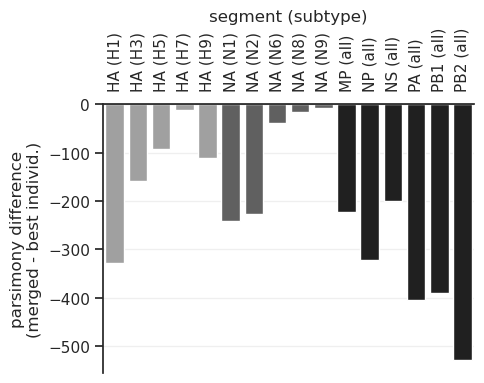

In [3]:
# Calculate parsimony improvement for each segment/subtype
improvements = []

for segment_subtype in dag_stats_df['segment_subtype'].unique():
    subset = dag_stats_df[dag_stats_df['segment_subtype'] == segment_subtype]
    individual = subset[subset['dag_type'] == 'individual']
    merged = subset[subset['dag_type'] == 'merged']
    
    if len(merged) > 0 and len(individual) > 0:
        best_individual = individual['min_parsimony'].min()
        merged_parsimony = merged['min_parsimony'].iloc[0]
        improvement = merged_parsimony - best_individual
        
        improvements.append({
            'segment_subtype': segment_subtype,
            'improvement': improvement,
            'best_individual': best_individual,
            'merged': merged_parsimony
        })

improvements_df = pd.DataFrame(improvements)

# Define custom order: HA segments first, then NA segments, then the rest alphabetically
ha_segments = sorted([s for s in improvements_df['segment_subtype'] if s.startswith('HA_')])
na_segments = sorted([s for s in improvements_df['segment_subtype'] if s.startswith('NA_')])
other_segments = sorted([s for s in improvements_df['segment_subtype'] if not s.startswith('HA_') and not s.startswith('NA_')])
segment_order = ha_segments + na_segments + other_segments

# Reorder dataframe
improvements_df_ordered = improvements_df.set_index('segment_subtype').loc[segment_order].reset_index()

# Convert segment_subtype format from "HA_H1" to "HA (H1)"
improvements_df_ordered['label'] = improvements_df_ordered['segment_subtype'].apply(
    lambda x: f"{x.split('_')[0]} ({x.split('_')[1]})" if '_' in x else x
)

# Create color palette based on segment type
colors = []
for segment in improvements_df_ordered['segment_subtype']:
    if segment.startswith('HA_'):
        colors.append('#a0a0a0')  # Medium-light gray for HA
    elif segment.startswith('NA_'):
        colors.append('#606060')  # Medium-dark gray for NA
    else:
        colors.append('#202020')  # Very dark gray for other segments

# Create bar plot using seaborn
fig, ax = plt.subplots(figsize=(5,4))

sns.barplot(x=improvements_df_ordered.index, y='improvement', hue=improvements_df_ordered.index,
            data=improvements_df_ordered, ax=ax, palette=colors, legend=False)

ax.set_xlabel('segment (subtype)')
ax.set_ylabel('parsimony difference\n(merged - best individ.)')

# Move x-axis to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Set x-tick labels
ax.set_xticks(range(len(improvements_df_ordered)))
ax.set_xticklabels(improvements_df_ordered['label'], rotation=90)

# Add horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

sns.despine(ax=ax, top=False, bottom=True)
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()